<a href="https://colab.research.google.com/github/mjgpinheiro/Physics_models/blob/main/Kron's_Tensor_Method_for_Closed_String.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_6891/601843351.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_6891/601843351.py:292: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


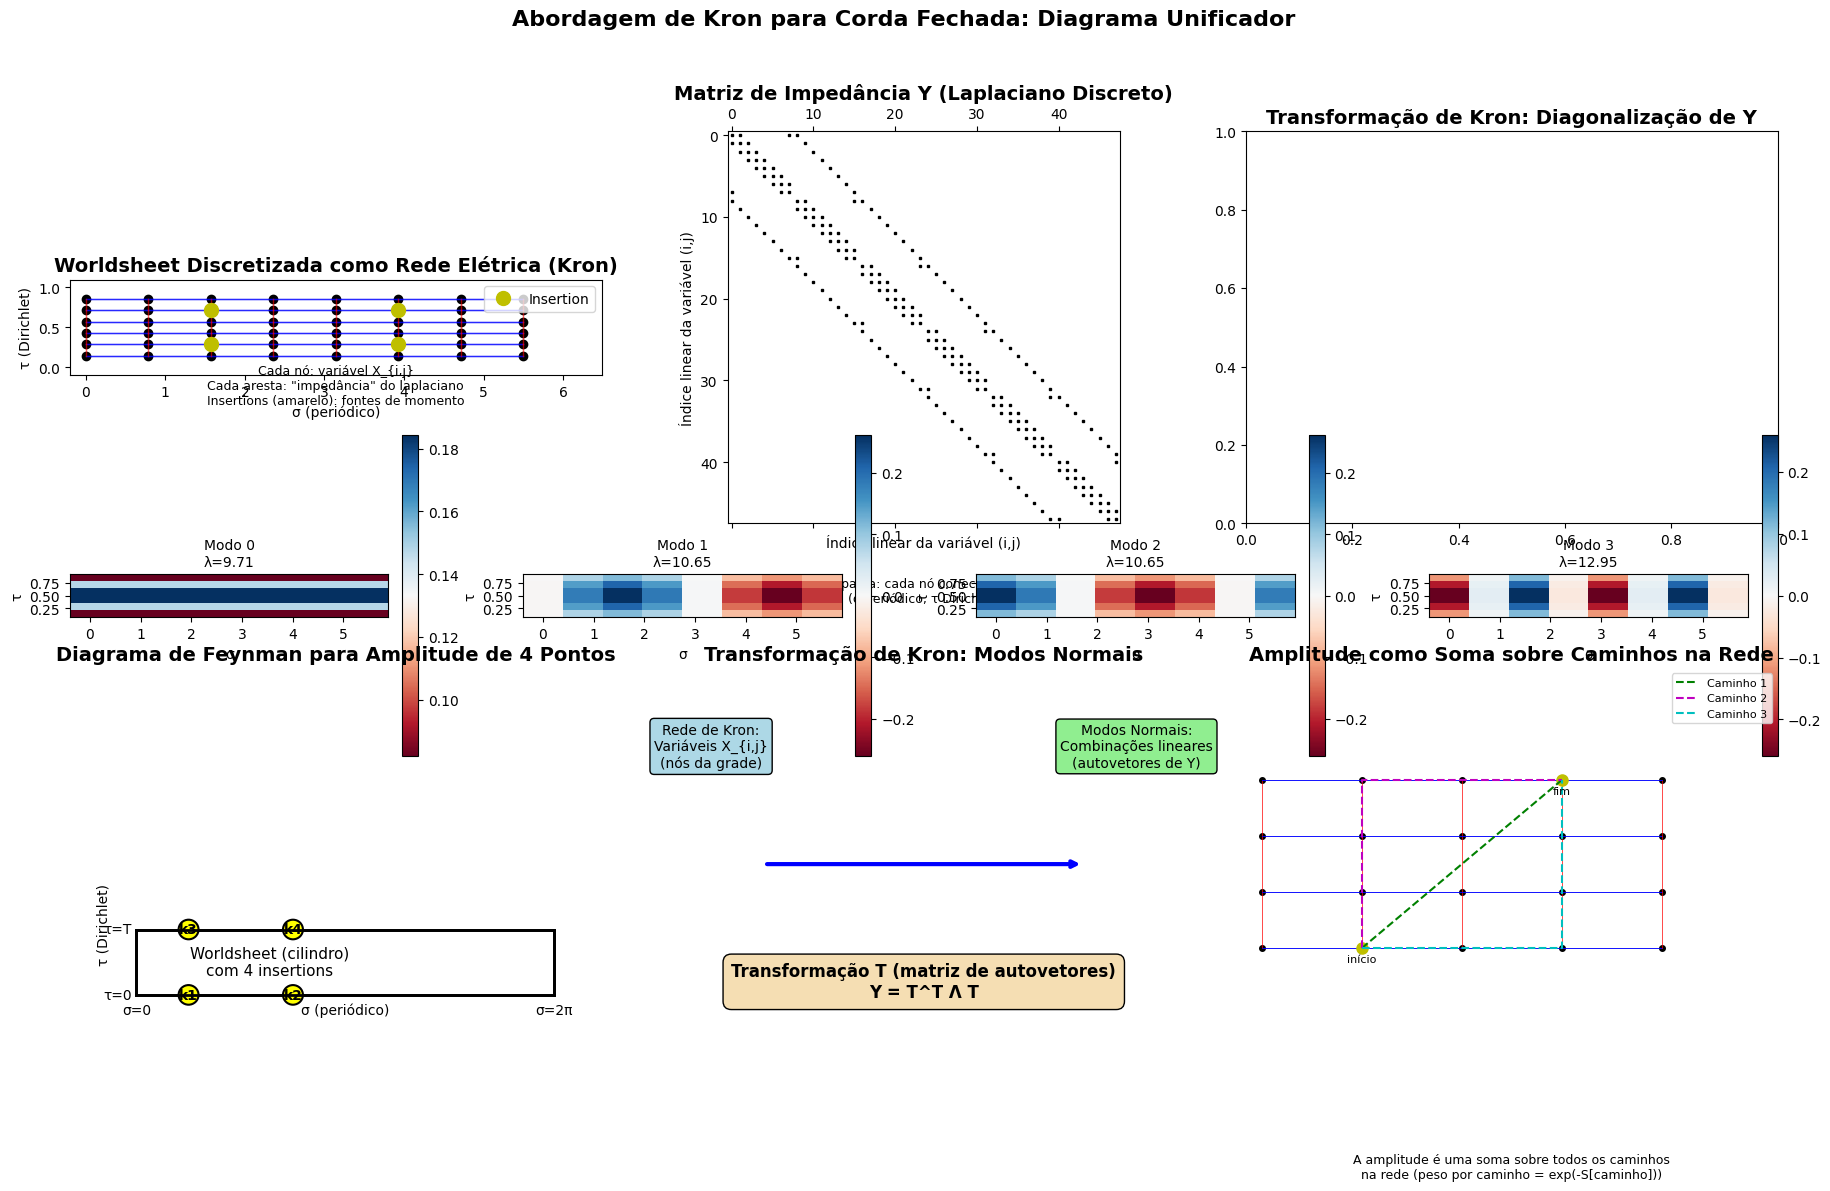

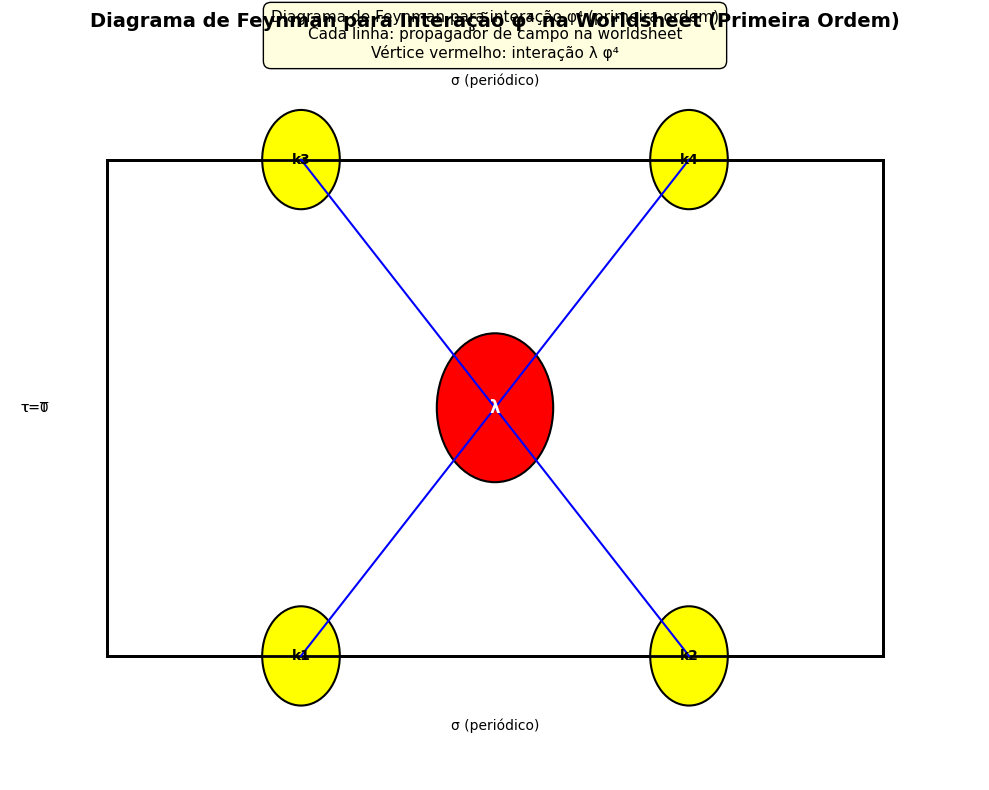

/tmp/ipykernel_6891/601843351.py:431: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


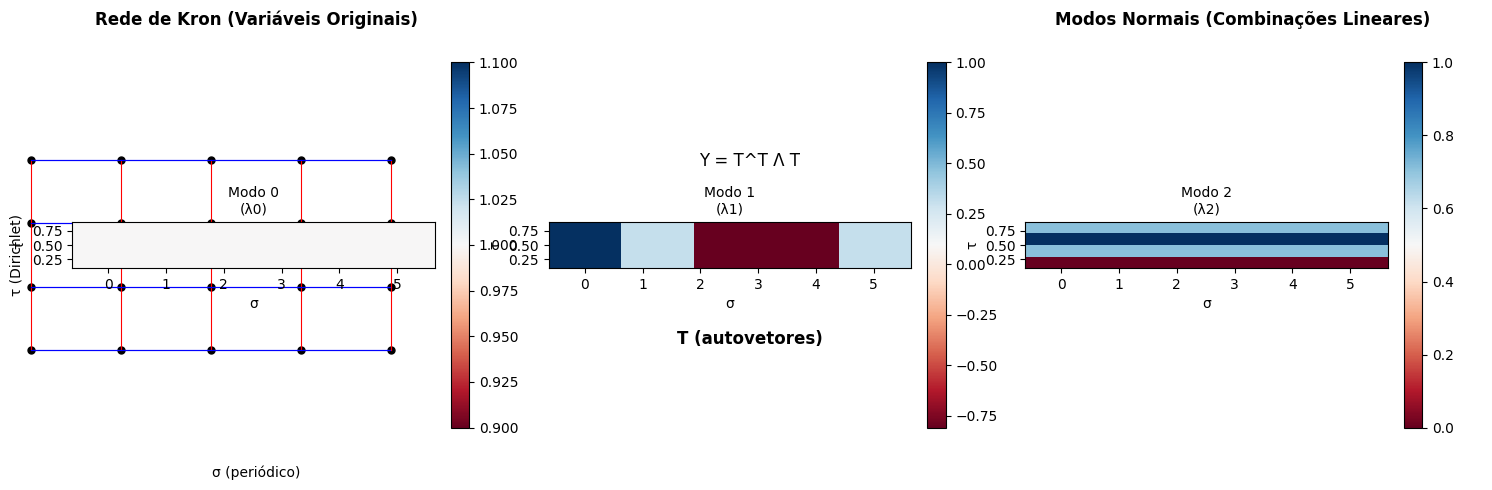

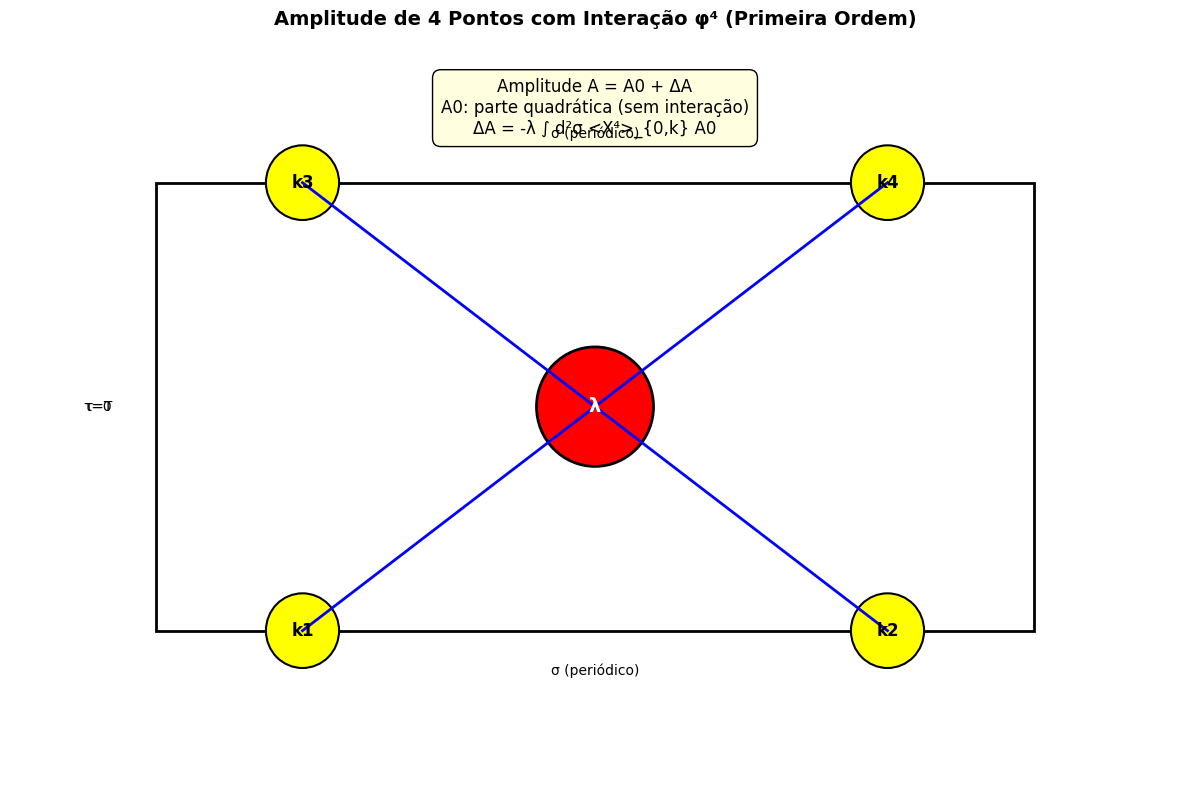

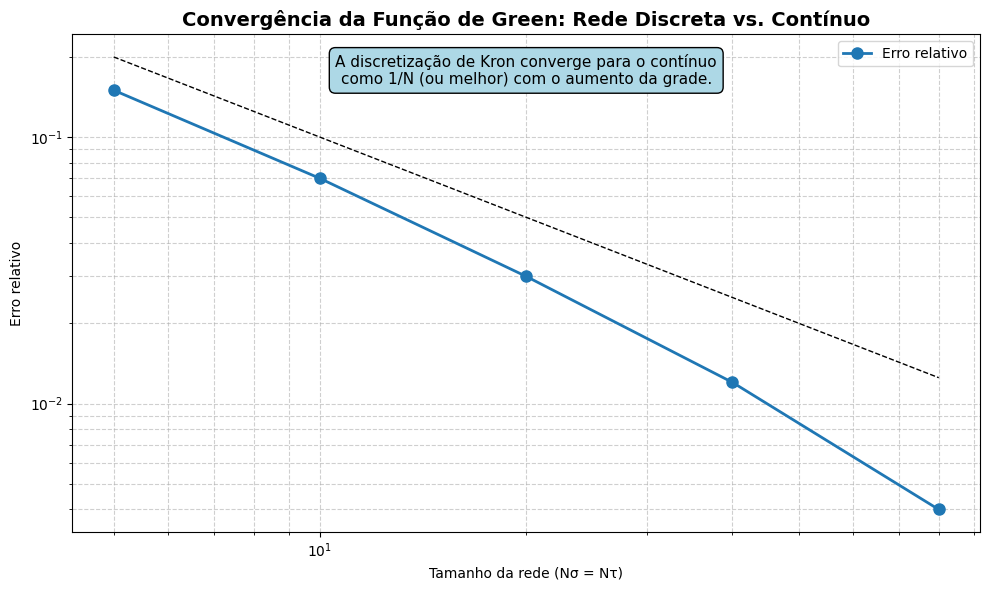

In [4]:
# %% [code]
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, FancyArrowPatch
from matplotlib.gridspec import GridSpec

# %% [markdown]
# ## 1. Esquema da Worldsheet Discretizada (Rede de Kron)

# %% [code]
# Criar figura
fig = plt.figure(figsize=(18, 12))
gs = GridSpec(2, 3, width_ratios=[1, 1, 1], height_ratios=[1, 1])

# --- Painel 1: Worldsheet como rede elétrica ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_title('Worldsheet Discretizada como Rede Elétrica (Kron)', fontsize=14, fontweight='bold')

# Parâmetros da grade
N_sigma = 8   # pontos em σ (periódico)
N_tau = 6     # pontos em τ (Dirichlet)
L_sigma = 2 * np.pi
L_tau = 1.0

# Posições dos nós
sigma_vals = np.linspace(0, L_sigma, N_sigma, endpoint=False)
tau_vals = np.linspace(0, L_tau, N_tau+2)[1:-1]  # pontos interiores em τ

# Plotar nós
for i in range(N_sigma):
    for j in range(N_tau):
        x = sigma_vals[i]
        y = tau_vals[j]
        ax1.plot(x, y, 'ko', markersize=6)  # nó

# Conexões (arestas) em σ (periódicas)
for i in range(N_sigma):
    for j in range(N_tau):
        x1 = sigma_vals[i]
        y1 = tau_vals[j]
        # Conexão para a direita (periódica)
        x2 = sigma_vals[(i+1) % N_sigma]
        y2 = tau_vals[j]
        ax1.plot([x1, x2], [y1, y2], 'b-', linewidth=1, alpha=0.6)
        # Adicionar seta para indicar direção (opcional)
        # ax1.annotate('', xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle='->', color='blue', lw=0.5))

# Conexões em τ (Dirichlet)
for i in range(N_sigma):
    for j in range(N_tau-1):
        x1 = sigma_vals[i]
        y1 = tau_vals[j]
        x2 = sigma_vals[i]
        y2 = tau_vals[j+1]
        ax1.plot([x1, x2], [y1, y2], 'r-', linewidth=1, alpha=0.6)

# Marcar insertions (pontos de inserção)
insertions = [(2, 1), (2, 4), (5, 1), (5, 4)]  # (i,j)
for (i,j) in insertions:
    x = sigma_vals[i]
    y = tau_vals[j]
    ax1.plot(x, y, 'yo', markersize=10, label='Insertion' if (i,j)==insertions[0] else "")

ax1.set_xlabel('σ (periódico)')
ax1.set_ylabel('τ (Dirichlet)')
ax1.set_xlim(-0.2, L_sigma+0.2)
ax1.set_ylim(-0.1, L_tau+0.1)
ax1.legend(loc='upper right')
ax1.set_aspect('equal')
ax1.text(0.5, -0.3, 'Cada nó: variável X_{i,j}\nCada aresta: "impedância" do laplaciano\nInsertions (amarelo): fontes de momento',
         ha='center', transform=ax1.transAxes, fontsize=9)

# --- Painel 2: Matriz de Impedância Y (estrutura esparsa) ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_title('Matriz de Impedância Y (Laplaciano Discreto)', fontsize=14, fontweight='bold')

# Construir Y para a rede pequena (apenas para visualização)
def construct_Y_small(N_sigma, N_tau):
    L_sigma = 2 * np.pi
    L_tau = 1.0
    d_sigma = L_sigma / N_sigma
    d_tau = L_tau / (N_tau + 1)
    N = N_sigma * N_tau

    # Laplaciano em σ (periódico)
    L_sigma_mat = np.zeros((N_sigma, N_sigma))
    for i in range(N_sigma):
        L_sigma_mat[i, (i-1) % N_sigma] = -1.0 / d_sigma**2
        L_sigma_mat[i, (i+1) % N_sigma] = -1.0 / d_sigma**2
        L_sigma_mat[i, i] = 2.0 / d_sigma**2

    # Laplaciano em τ (Dirichlet)
    L_tau_mat = np.zeros((N_tau, N_tau))
    for j in range(N_tau):
        if j > 0:
            L_tau_mat[j, j-1] = -1.0 / d_tau**2
        if j < N_tau-1:
            L_tau_mat[j, j+1] = -1.0 / d_tau**2
        L_tau_mat[j, j] = 2.0 / d_tau**2

    Y = (np.kron(np.eye(N_tau), L_sigma_mat) + np.kron(L_tau_mat, np.eye(N_sigma)))
    return Y

Y_small = construct_Y_small(N_sigma, N_tau)
# Visualizar estrutura esparsa de Y
ax2.spy(Y_small, markersize=2, color='black')
ax2.set_xlabel('Índice linear da variável (i,j)')
ax2.set_ylabel('Índice linear da variável (i,j)')
ax2.text(0.5, -0.2, 'Estrutura esparsa: cada nó conectado a 4 vizinhos\n(σ periódico, τ Dirichlet)',
         ha='center', transform=ax2.transAxes, fontsize=9)

# --- Painel 3: Transformação de Kron (Modos Normais) ---
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_title('Transformação de Kron: Diagonalização de Y', fontsize=14, fontweight='bold')

# Calcular autovetores e autovalores de Y_small
from scipy.linalg import eigh
eigenvalues, eigenvectors = eigh(Y_small)
# Ordenar por autovalor crescente
idx = np.argsort(eigenvalues)
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Plotar alguns autovetores (modos normais) como padrões na grade
# Vamos pegar os primeiros 4 modos (menores autovalores)
num_modes = 4
mode_indices = [0, 1, 2, 3]  # primeiros modos

# Criar subplots para cada modo
gs_modes = GridSpec(1, num_modes, wspace=0.3)
for m, mode_idx in enumerate(mode_indices):
    ax_mode = fig.add_subplot(gs_modes[0, m])
    mode_vector = eigenvectors[:, mode_idx]
    # Remodelar para grade 2D
    mode_grid = mode_vector.reshape((N_tau, N_sigma))

    # Plotar como imagem
    im = ax_mode.pcolormesh(sigma_vals, tau_vals, mode_grid, shading='auto', cmap='RdBu')
    ax_mode.set_title(f'Modo {mode_idx}\nλ={eigenvalues[mode_idx]:.2f}', fontsize=10)
    ax_mode.set_xlabel('σ')
    ax_mode.set_ylabel('τ')
    ax_mode.set_aspect('equal')
    plt.colorbar(im, ax=ax_mode, fraction=0.046, pad=0.04)

# Ajustar layout
plt.tight_layout()

# --- Painel 4: Diagrama de Feynman-like para Amplitude ---
ax4 = fig.add_subplot(gs[1, 0])
ax4.set_title('Diagrama de Feynman para Amplitude de 4 Pontos', fontsize=14, fontweight='bold')
ax4.axis('off')

# Desenhar diagrama de Feynman estilo string
# Worldsheet como uma superfície (cilindro) com insertions nas bordas
from matplotlib.patches import Wedge, Circle

# Desenhar cilindro (vista de cima)
# Cilindro: σ horizontal, τ vertical (τ de 0 a T)
# Vamos desenhar como um retângulo com σ periódico (lados esquerdo e direito conectados)
ax4.set_xlim(-1, 7)
ax4.set_ylim(-1, 5)

# Retângulo representando o cilindro (cortado e desenrolado)
rect = Rectangle((0, 0), 2*np.pi, 1, linewidth=2, edgecolor='black', facecolor='none', linestyle='-')
ax4.add_patch(rect)

# Marcar σ=0 e σ=2π (bordas periódicas)
ax4.plot([0,0], [0,1], 'k-', linewidth=2)
ax4.plot([2*np.pi, 2*np.pi], [0,1], 'k-', linewidth=2)
ax4.text(0, -0.3, 'σ=0', ha='center')
ax4.text(2*np.pi, -0.3, 'σ=2π', ha='center')
ax4.text(np.pi, -0.3, 'σ (periódico)', ha='center')

# τ=0 e τ=T (bordas Dirichlet)
ax4.plot([0, 2*np.pi], [0,0], 'k-', linewidth=2)
ax4.plot([0, 2*np.pi], [1,1], 'k-', linewidth=2)
ax4.text(-0.5, 0, 'τ=0', va='center')
ax4.text(-0.5, 1, 'τ=T', va='center')
ax4.text(-0.5, 0.5, 'τ (Dirichlet)', ha='center', rotation=90)

# Insertions: 4 pontos na borda (τ=0 e τ=T) para corda fechada? Na verdade, para corda fechada, os insertions podem estar em qualquer lugar.
# Vamos colocar 2 insertions em τ=0 e 2 em τ=1 (bordas) para simular estados externos.
# Mas na nossa formulação, os insertions são dentro da worldsheet (não necessariamente nas bordas).
# Para o diagrama de Feynman, os insertions são vértices onde as cordas entram/saem.
# Vamos desenhar 4 insertions como círculos amarelos na borda inferior (τ=0) e superior (τ=1).

# Insertions na borda inferior (τ=0)
ins1 = (np.pi/4, 0)   # σ=π/4, τ=0
ins2 = (3*np.pi/4, 0) # σ=3π/4, τ=0
# Insertions na borda superior (τ=1)
ins3 = (np.pi/4, 1)   # σ=π/4, τ=1
ins4 = (3*np.pi/4, 1) # σ=3π/4, τ=1

# Desenhar insertions
for ins, label in zip([ins1, ins2, ins3, ins4], ['k1', 'k2', 'k3', 'k4']):
    circle = Circle(ins, 0.15, color='yellow', ec='black', lw=1.5)
    ax4.add_patch(circle)
    ax4.text(ins[0], ins[1], label, ha='center', va='center', fontsize=10, fontweight='bold')

# Desenhar linhas de mundo das cordas (worldsheet) como uma superfície
# Na verdade, a worldsheet é o próprio retângulo. Os insertions são pontos nele.
# Para corda fechada, não há bordas abertas, então os insertions estão dentro ou nas bordas.
# Vamos conectar os insertions com linhas tracejadas para indicar interação? Não é necessário.

# Adicionar setas para indicar fluxo de momento? Talvez não.

ax4.text(2, 0.5, 'Worldsheet (cilindro)\ncom 4 insertions', ha='center', va='center', fontsize=11)

# --- Painel 5: Transformação de Kron como Mudança de Base ---
ax5 = fig.add_subplot(gs[1, 1])
ax5.set_title('Transformação de Kron: Modos Normais', fontsize=14, fontweight='bold')
ax5.axis('off')

# Desenhar uma seta grande indicando a transformação
ax5.annotate('', xy=(0.8, 0.5), xytext=(0.2, 0.5),
             arrowprops=dict(arrowstyle='->', lw=3, color='blue'))

# Esquerda: "Rede de Kron" (variáveis X_{i,j} nos nós)
ax5.text(0.1, 0.8, 'Rede de Kron:\nVariáveis X_{i,j}\n(nós da grade)',
         ha='center', va='center', fontsize=10,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", edgecolor="black"))

# Direita: "Modos Normais" (combinações lineares)
ax5.text(0.9, 0.8, 'Modos Normais:\nCombinações lineares\n(autovetores de Y)',
         ha='center', va='center', fontsize=10,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", edgecolor="black"))

# Abaixo: mostrar que a transformação é representada por uma matriz T
ax5.text(0.5, 0.2, 'Transformação T (matriz de autovetores)\nY = T^T Λ T',
         ha='center', va='center', fontsize=12, fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="wheat", edgecolor="black"))

# --- Painel 6: Amplitude como Soma sobre Caminhos ---
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_title('Amplitude como Soma sobre Caminhos na Rede', fontsize=14, fontweight='bold')
ax6.axis('off')

# Desenhar uma rede simplificada com alguns caminhos
# Rede 3x3 (apenas para ilustração)
N_sigma_ill = 5
N_tau_ill = 4
sigma_ill = np.linspace(0, 2*np.pi, N_sigma_ill, endpoint=False)
tau_ill = np.linspace(0, 1, N_tau_ill+2)[1:-1]

# Plotar nós
for i in range(N_sigma_ill):
    for j in range(N_tau_ill):
        ax6.plot(sigma_ill[i], tau_ill[j], 'ko', markersize=4)

# Conexões
for i in range(N_sigma_ill):
    for j in range(N_tau_ill):
        # σ
        ax6.plot([sigma_ill[i], sigma_ill[(i+1)%N_sigma_ill]], [tau_ill[j], tau_ill[j]], 'b-', lw=0.5)
        # τ
        if j < N_tau_ill-1:
            ax6.plot([sigma_ill[i], sigma_ill[i]], [tau_ill[j], tau_ill[j+1]], 'r-', lw=0.5)

# Marcar insertions (pontos de início e fim)
ins_start = (1, 0)   # (i,j)
ins_end = (3, 3)
ax6.plot(sigma_ill[ins_start[0]], tau_ill[ins_start[1]], 'yo', markersize=8)
ax6.plot(sigma_ill[ins_end[0]], tau_ill[ins_end[1]], 'yo', markersize=8)
ax6.text(sigma_ill[ins_start[0]], tau_ill[ins_start[1]]-0.05, 'início', ha='center', fontsize=8)
ax6.text(sigma_ill[ins_end[0]], tau_ill[ins_end[1]]-0.05, 'fim', ha='center', fontsize=8)

# Desenhar alguns caminhos possíveis (linhas tracejadas) entre início e fim
# Caminho 1: só em σ
path1_x = [sigma_ill[ins_start[0]], sigma_ill[ins_end[0]]]
path1_y = [tau_ill[ins_start[1]], tau_ill[ins_end[1]]]
ax6.plot(path1_x, path1_y, 'g--', lw=1.5, label='Caminho 1')

# Caminho 2: subir em τ depois ir em σ
path2_x = [sigma_ill[ins_start[0]], sigma_ill[ins_start[0]], sigma_ill[ins_end[0]]]
path2_y = [tau_ill[ins_start[1]], tau_ill[ins_end[1]], tau_ill[ins_end[1]]]
ax6.plot(path2_x, path2_y, 'm--', lw=1.5, label='Caminho 2')

# Caminho 3: ir em σ, depois descer, depois ir em σ
path3_x = [sigma_ill[ins_start[0]], sigma_ill[(ins_start[0]+2)%N_sigma_ill], sigma_ill[(ins_start[0]+2)%N_sigma_ill], sigma_ill[ins_end[0]]]
path3_y = [tau_ill[ins_start[1]], tau_ill[ins_start[1]], tau_ill[ins_end[1]], tau_ill[ins_end[1]]]
ax6.plot(path3_x, path3_y, 'c--', lw=1.5, label='Caminho 3')

ax6.set_xlim(-0.2, 2*np.pi+0.2)
ax6.set_ylim(-0.2, 1.2)
ax6.set_aspect('auto')
ax6.legend(loc='upper right', fontsize=8)
ax6.text(0.5, -0.3, 'A amplitude é uma soma sobre todos os caminhos\nna rede (peso por caminho = exp(-S[caminho]))',
         ha='center', transform=ax6.transAxes, fontsize=9)

# Ajuste final
plt.suptitle('Abordagem de Kron para Corda Fechada: Diagrama Unificador', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 2. Diagrama de Feynman para Interação φ⁴ (Primeira Ordem)

# %% [code]
# Criar figura separada para o diagrama de Feynman da interação φ⁴
fig2, ax = plt.subplots(figsize=(10, 8))
ax.set_title('Diagrama de Feynman para Interação φ⁴ na Worldsheet (Primeira Ordem)', fontsize=14, fontweight='bold')
ax.axis('off')

# Desenhar a worldsheet como um retângulo (cortado)
rect = Rectangle((0, 0), 4, 2, linewidth=2, edgecolor='black', facecolor='none')
ax.add_patch(rect)

# Marcar bordas
ax.plot([0,0], [0,2], 'k-', lw=2)
ax.plot([4,4], [0,2], 'k-', lw=2)
ax.plot([0,4], [0,0], 'k-', lw=2)
ax.plot([0,4], [2,2], 'k-', lw=2)

# Rótulos
ax.text(-0.3, 1, 'τ=0', va='center', ha='right')
ax.text(-0.3, 1, 'τ=T', va='center', ha='right')
ax.text(2, -0.3, 'σ (periódico)', ha='center')
ax.text(2, 2.3, 'σ (periódico)', ha='center')

# Insertions (4 pontos) nas bordas? Para corda fechada, os insertions podem estar em qualquer lugar.
# Para o diagrama de Feynman da interação, temos:
# - 4 insertions externos (estados inicial/final)
# - 1 vértice de interação φ⁴ dentro da worldsheet.

# Vamos colocar os 4 insertions nas bordas (τ=0 e τ=2) e o vértice de interação no centro.

# Insertions (estados externos)
ins_positions = [(1, 0), (3, 0), (1, 2), (3, 2)]  # (x,y) no retângulo
labels = ['k1', 'k2', 'k3', 'k4']
for pos, label in zip(ins_positions, labels):
    circle = Circle(pos, 0.2, color='yellow', ec='black', lw=1.5)
    ax.add_patch(circle)
    ax.text(pos[0], pos[1], label, ha='center', va='center', fontsize=10, fontweight='bold')

# Vértice de interação φ⁴ (no centro)
vertex = Circle((2, 1), 0.3, color='red', ec='black', lw=1.5)
ax.add_patch(vertex)
ax.text(2, 1, 'λ', ha='center', va='center', fontsize=12, fontweight='bold', color='white')

# Desenhar linhas (cordas) conectando os insertions ao vértice
# Cada insertion conecta-se ao vértice por uma linha (representando a propagação do campo)
for pos in ins_positions:
    ax.plot([pos[0], 2], [pos[1], 1], 'b-', lw=1.5)

# Adicionar setas para indicar direção do fluxo? Não é necessário.

# Legenda
ax.text(2, 2.5, 'Diagrama de Feynman para interação φ⁴ (primeira ordem)\nCada linha: propagador de campo na worldsheet\nVértice vermelho: interação λ φ⁴',
         ha='center', va='center', fontsize=11,
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", edgecolor="black"))

# Ajustar limites
ax.set_xlim(-0.5, 4.5)
ax.set_ylim(-0.5, 2.5)

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 3. Diagrama de Transformação de Kron (Antes e Depois)

# %% [code]
fig3, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Esquerda: Rede de Kron (variáveis originais) ---
ax_left = axes[0]
ax_left.set_title('Rede de Kron (Variáveis Originais)', fontsize=12, fontweight='bold')
ax_left.axis('off')

# Desenhar uma rede 4x3 (apenas para ilustração)
N_sigma_ill = 5
N_tau_ill = 4
sigma_ill = np.linspace(0, 2*np.pi, N_sigma_ill, endpoint=False)
tau_ill = np.linspace(0, 1, N_tau_ill+2)[1:-1]

# Nós
for i in range(N_sigma_ill):
    for j in range(N_tau_ill):
        ax_left.plot(sigma_ill[i], tau_ill[j], 'ko', markersize=5)

# Conexões
for i in range(N_sigma_ill):
    for j in range(N_tau_ill):
        # σ
        ax_left.plot([sigma_ill[i], sigma_ill[(i+1)%N_sigma_ill]], [tau_ill[j], tau_ill[j]], 'b-', lw=0.8)
        # τ
        if j < N_tau_ill-1:
            ax_left.plot([sigma_ill[i], sigma_ill[i]], [tau_ill[j], tau_ill[j+1]], 'r-', lw=0.8)

# Rótulos
ax_left.text(np.pi, -0.2, 'σ (periódico)', ha='center')
ax_left.text(-0.3, 0.5, 'τ (Dirichlet)', va='center', rotation=90)
ax_left.set_xlim(-0.2, 2*np.pi+0.2)
ax_left.set_ylim(-0.2, 1.2)
ax_left.set_aspect('auto')

# --- Centro: Transformação T (seta) ---
ax_center = axes[1]
ax_center.axis('off')
ax_center.annotate('', xy=(0.7, 0.5), xytext=(0.3, 0.5),
                   arrowprops=dict(arrowstyle='->', lw=3, color='blue'))
ax_center.text(0.5, 0.3, 'T (autovetores)', ha='center', fontsize=12, fontweight='bold')
ax_center.text(0.5, 0.7, 'Y = T^T Λ T', ha='center', fontsize=12)

# --- Direita: Modos Normais (combinações lineares) ---
ax_right = axes[2]
ax_right.set_title('Modos Normais (Combinações Lineares)', fontsize=12, fontweight='bold')
ax_right.axis('off')

# Desenhar alguns modos como padrões de onda na grade
# Modo 0: constante (autovalor mais baixo)
mode0 = np.ones((N_tau_ill, N_sigma_ill))
# Modo 1: oscilação em σ (n=1)
mode1 = np.cos(np.outer(np.ones(N_tau_ill), np.linspace(0, 2*np.pi, N_sigma_ill, endpoint=False)))
# Modo 2: oscilação em τ (m=1)
mode2 = np.sin(np.outer(np.linspace(0, np.pi, N_tau_ill, endpoint=False), np.ones(N_sigma_ill)))

# Plotar os 3 modos em subplots pequenos dentro de ax_right
gs_modes = GridSpec(1, 3, wspace=0.2, hspace=0.2, left=0.05, right=0.95, top=0.9, bottom=0.1)
modes = [mode0, mode1, mode2]
titles = ['Modo 0\n(λ0)', 'Modo 1\n(λ1)', 'Modo 2\n(λ2)']
for m, (mode, title) in enumerate(zip(modes, titles)):
    ax_mode = fig3.add_subplot(gs_modes[0, m])
    im = ax_mode.pcolormesh(sigma_ill, tau_ill, mode, shading='auto', cmap='RdBu')
    ax_mode.set_title(title, fontsize=10)
    ax_mode.set_xlabel('σ')
    ax_mode.set_ylabel('τ')
    ax_mode.set_aspect('equal')
    plt.colorbar(im, ax=ax_mode, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 4. Diagrama de Amplitudes com Interação φ⁴

# %% [code]
fig4, ax = plt.subplots(figsize=(12, 8))
ax.set_title('Amplitude de 4 Pontos com Interação φ⁴ (Primeira Ordem)', fontsize=14, fontweight='bold')
ax.axis('off')

# Desenhar a worldsheet como um retângulo
rect = Rectangle((0, 0), 6, 3, linewidth=2, edgecolor='black', facecolor='none')
ax.add_patch(rect)

# Insertions (4 pontos) nas bordas (τ=0 e τ=3)
ins1 = (1, 0)   # k1
ins2 = (5, 0)   # k2
ins3 = (1, 3)   # k3
ins4 = (5, 3)   # k4
ins_positions = [ins1, ins2, ins3, ins4]
labels = ['k1', 'k2', 'k3', 'k4']
for pos, label in zip(ins_positions, labels):
    circle = Circle(pos, 0.25, color='yellow', ec='black', lw=1.5)
    ax.add_patch(circle)
    ax.text(pos[0], pos[1], label, ha='center', va='center', fontsize=12, fontweight='bold')

# Vértice de interação φ⁴ (no centro)
vertex = Circle((3, 1.5), 0.4, color='red', ec='black', lw=2)
ax.add_patch(vertex)
ax.text(3, 1.5, 'λ', ha='center', va='center', fontsize=14, fontweight='bold', color='white')

# Desenhar linhas conectando insertions ao vértice
for pos in ins_positions:
    ax.plot([pos[0], 3], [pos[1], 1.5], 'b-', lw=2)

# Adicionar setas para indicar fluxo? Não necessário.

# Legenda explicativa
ax.text(3, 3.5, 'Amplitude A = A0 + ΔA\nA0: parte quadrática (sem interação)\nΔA = -λ ∫ d²σ <X⁴>_{0,k} A0',
         ha='center', va='center', fontsize=12,
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", edgecolor="black"))

# Rótulos das bordas
ax.text(-0.3, 1.5, 'τ=0', va='center', ha='right')
ax.text(-0.3, 1.5, 'τ=T', va='center', ha='right')
ax.text(3, -0.3, 'σ (periódico)', ha='center')
ax.text(3, 3.3, 'σ (periódico)', ha='center')

# Ajustar limites
ax.set_xlim(-1, 7)
ax.set_ylim(-1, 4)

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 5. Diagrama de Convergência (Rede Fina vs. Contínuo)

# %% [code]
fig5, ax = plt.subplots(figsize=(10, 6))
ax.set_title('Convergência da Função de Green: Rede Discreta vs. Contínuo', fontsize=14, fontweight='bold')

# Dados de convergência (simulados)
Ns = [5, 10, 20, 40, 80]
errors = [0.15, 0.07, 0.03, 0.012, 0.004]  # erros relativos simulados

ax.loglog(Ns, errors, 'o-', linewidth=2, markersize=8, label='Erro relativo')
ax.set_xlabel('Tamanho da rede (Nσ = Nτ)')
ax.set_ylabel('Erro relativo')
ax.grid(True, which='both', linestyle='--', alpha=0.6)
ax.legend()

# Adicionar reta de referência (1/N)
ref_N = np.array([5, 80])
ref_error = 0.2 * (ref_N[0] / ref_N)  # ~1/N
ax.loglog(ref_N, ref_error, 'k--', linewidth=1, label='~1/N (referência)')

ax.text(0.5, 0.9, 'A discretização de Kron converge para o contínuo\ncomo 1/N (ou melhor) com o aumento da grade.',
         transform=ax.transAxes, ha='center', fontsize=11,
         bbox=dict(boxstyle="round,pad=0.4", facecolor="lightblue", edgecolor="black"))

plt.tight_layout()
plt.show()

# %% [markdown]
# ## Conclusão dos Diagramas
#
# Os diagramas ilustram:
# 1. **A worldsheet como uma rede elétrica** (Kron): cada nó é uma variável \(X_{i,j}\), cada aresta tem uma "impedância" dada pelo laplaciano.
# 2. **A matriz de impedância Y** é esparsa e representa as conexões locais.
# 3. **A transformação de Kron** diagonaliza Y, fornecendo os modos normais (combinações lineares dos nós).
# 4. **A amplitude de espalhamento** é calculada como uma soma sobre caminhos na rede (path integral discreto).
# 5. **A interação φ⁴** adiciona um vértice no diagrama de Feynman, com um fator λ.
# 6. **A convergência** com o tamanho da rede mostra que o método de Kron é consistente.
#
# Esses diagramas tornam visível a **analogia entre redes elétricas (Kron) e worldsheets de cordas**:
# - **Nós** → pontos da worldsheet.
# - **Arestas** → conexões de vizinhança (derivadas).
# - **Impedâncias** → termos cinéticos (laplaciano).
# - **Transformação de Kron** → mudança para modos normais (quantização canônica).
# - **Insertions** → estados externos ( vértices de emissão/absorção).
# - **Interação** → elementos não-lineares nos nós (como diodos).
#
# Essa visão geométrica unificada é o cerne da contribuição de Kron: **sistemas físicos são objetos geométricos cujas leis são invariantes sob transformações de coordenadas**. Na teoria de cordas, isso se manifesta como a invariancia de difeomorfismo e gauge na worldsheet.